In [1]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


In [2]:
import os
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import albumentations as A
import segmentation_models_pytorch as smp
from albumentations.pytorch import ToTensorV2

In [3]:
# ==========================================
# 1. КОНФИГУРАЦИЯ И НАСТРОЙКИ
# ==========================================
TEST_IMAGES_DIR = Path(r"/kaggle/input/competitions/dl-lab-3-product-segmentation/test_images")

# ПУТИ К ВЕСАМ
WEIGHTS_DIR_CONF1 = Path(r"/kaggle/input/datasets/tkachenko1van/conf1-unetpp-effb4")
WEIGHTS_DIR_CONF2 = Path(r"/kaggle/input/datasets/tkachenko1van/conf2-manet-mitb3")
WEIGHTS_DIR_CONF3 = Path(r"/kaggle/input/datasets/tkachenko1van/conf3-deeplab-convnext") 

OUTPUT_CSV = "submission_ensemble_best_params.csv"

IMG_SIZE = 320
THRESHOLD = 0.3936
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [4]:
# ==========================================
# 2. ЗАГРУЗКА МОДЕЛЕЙ (С идеальными OOF весами)
# ==========================================
models_with_weights = []

# Загружаем Conf 1 (Unet++ | eff-b4) -> Вес 0.1891
for fold in range(1, 6):
    weight_path = WEIGHTS_DIR_CONF1 / f"conf1_unetpp_effb4_fold{fold}.pth"
    if weight_path.exists():
        model = smp.UnetPlusPlus(encoder_name="efficientnet-b4", encoder_weights=None, in_channels=3, classes=1)
        model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        models_with_weights.append((model, 0.1891))

# Загружаем Conf 2 (MAnet | mit_b3) -> Вес 0.4435
for fold in range(1, 6):
    weight_path = WEIGHTS_DIR_CONF2 / f"conf2_manet_mitb3_fold{fold}.pth"
    if weight_path.exists():
        model = smp.MAnet(encoder_name="mit_b3", encoder_weights=None, in_channels=3, classes=1)
        model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        models_with_weights.append((model, 0.4435))

# Загружаем Conf 3 (DeepLabV3+ | convnext_small) -> Вес 0.3673
for fold in range(1, 6):
    weight_path = WEIGHTS_DIR_CONF3 / f"conf3_deeplab_convnext_fold{fold}.pth"
    if weight_path.exists():
        model = smp.DeepLabV3Plus(encoder_name="tu-convnext_small", encoder_weights=None, in_channels=3, classes=1)
        model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        models_with_weights.append((model, 0.3673))
        
print(f"✅ Всего загружено моделей в ансамбль: {len(models_with_weights)}")

✅ Всего загружено моделей в ансамбль: 15


In [5]:
# ==========================================
# 3. ПОСТПРОЦЕССИНГ (Очистка маски)
# ==========================================
def postprocess_mask(mask: np.ndarray) -> np.ndarray:
    # 1. Выделение наибольшей компоненты связности (LCC)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest_label).astype(np.uint8)
    else:
        return np.zeros_like(mask)
    
    # 2. Заливка дырок (Против бликов)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cv2.drawContours(mask, contours, -1, 1, thickness=cv2.FILLED)
        
    return mask

def serialize_mask(mask2d: np.ndarray) -> str:
    return json.dumps(mask2d.tolist(), separators=(",", ":"))

In [6]:
# ==========================================
# 4. ФУНКЦИЯ ПРЕДСКАЗАНИЯ (Взвешенный Ансамбль)
# ==========================================
def predict_image(image_bgr: np.ndarray, models_with_weights: list, threshold=THRESHOLD) -> np.ndarray:
    original_h, original_w = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    augmented = val_transform(image=image_rgb)
    img_orig = augmented['image'].unsqueeze(0).to(DEVICE)

    # TTA: Создаем отражения
    img_h  = torch.flip(img_orig, dims=[3])
    img_v  = torch.flip(img_orig, dims=[2])
    img_hv = torch.flip(img_orig, dims=[2, 3])

    ensemble_probs = torch.zeros((1, 1, IMG_SIZE, IMG_SIZE), device=DEVICE)
    total_weight = 0.0
    
    for model, weight in models_with_weights:
        with torch.amp.autocast('cuda'):
            prob_orig = torch.sigmoid(model(img_orig))
            prob_h = torch.flip(torch.sigmoid(model(img_h)), dims=[3])
            prob_v = torch.flip(torch.sigmoid(model(img_v)), dims=[2])
            prob_hv = torch.flip(torch.sigmoid(model(img_hv)), dims=[2, 3])
            
            # Умножаем сумму TTA-предсказаний одной модели на её вес
            model_probs = (prob_orig + prob_h + prob_v + prob_hv)
            ensemble_probs += (model_probs * weight)
            
            total_weight += (4.0 * weight)
            
    ensemble_probs /= total_weight
    
    probs_np = ensemble_probs[0, 0].cpu().numpy().astype(np.float32)
    
    if probs_np.shape != (original_h, original_w):
        probs_np = cv2.resize(probs_np, (original_w, original_h), interpolation=cv2.INTER_LINEAR)
        
    binary_mask = (probs_np > threshold).astype(np.uint8)
    final_mask = postprocess_mask(binary_mask)
    
    return final_mask

In [8]:
image_paths = sorted(list(TEST_IMAGES_DIR.glob("*.jpg"))) + sorted(list(TEST_IMAGES_DIR.glob("*.png")))
print(f"📸 Найдено тестовых изображений: {len(image_paths)}")

📸 Найдено тестовых изображений: 2000


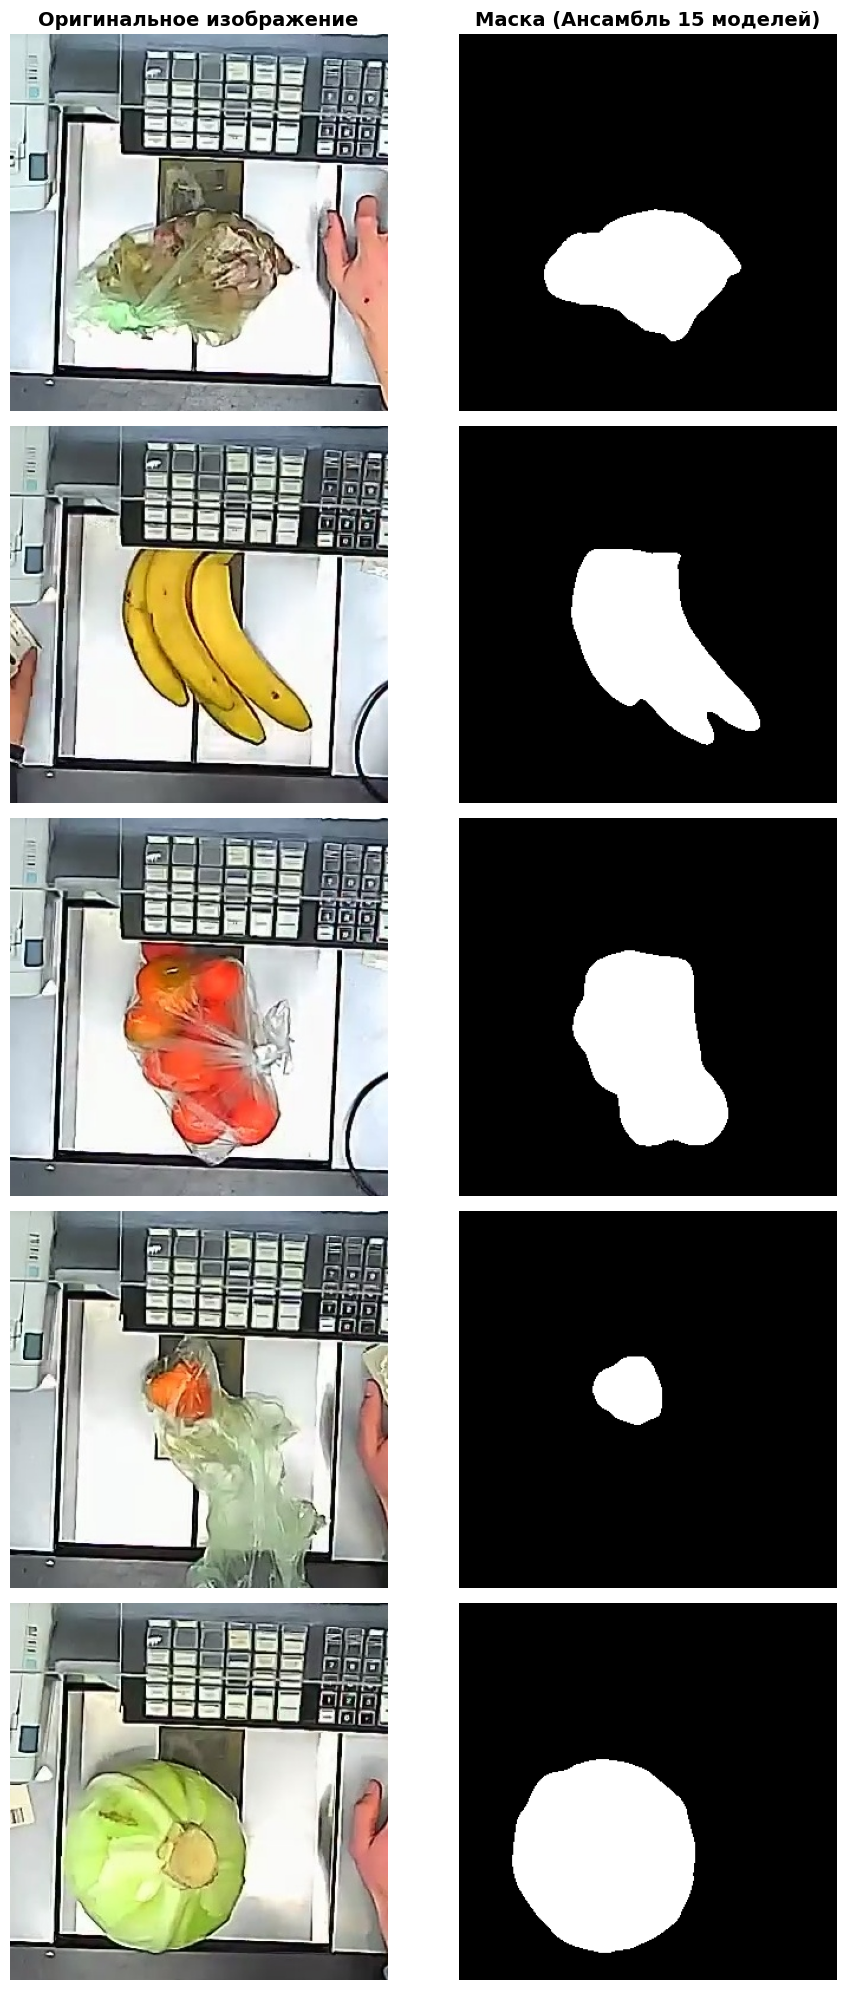

In [9]:
# ==========================================
# 5. ВИЗУАЛЬНАЯ ПРОВЕРКА (5 КАРТИНОК)
# ==========================================
sample_paths = image_paths[:5]
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 20))

axes[0, 0].set_title("Оригинальное изображение", fontsize=14, fontweight='bold')
axes[0, 1].set_title("Маска (Ансамбль 15 моделей)", fontsize=14, fontweight='bold')

for ax in axes.flatten():
    ax.axis('off')

with torch.inference_mode():
    for i, img_path in enumerate(sample_paths):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        mask = predict_image(img_bgr, models_with_weights)

        axes[i, 0].imshow(img_rgb)
        axes[i, 1].imshow(mask, cmap='gray')

plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# 6. ИНФЕРЕНС И САБМИТ
# ==========================================
submission_data = []

with torch.inference_mode():
    for img_path in tqdm(image_paths, desc="Инференс ансамбля"):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            print(f"[skip] Ошибка чтения: {img_path}")
            continue

        final_mask = predict_image(img_bgr, models_with_weights)

        submission_data.append({
            "ImageId": img_path.name,
            "mask": serialize_mask(final_mask),
        })

submission_df = pd.DataFrame(submission_data)
submission_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"🎉 Готово! Сабмит сохранен в: {OUTPUT_CSV}")

Инференс ансамбля: 100%|██████████| 2000/2000 [47:32<00:00,  1.43s/it]


🎉 Готово! Сабмит сохранен в: submission_ensemble_best_params.csv
